# DeepSeek-V4-Flash-Vision-Exp — vision on 4x CMP 170HX (SM80), vLLM

| Metric | Value |
|---|---|
| Decode, c=1 (text-only / text+image) | 163.06 tok/s / 45.32 tok/s aggregate |
| Best aggregate throughput | 163.06 tok/s at c=1, text-only (c=4 crashed mid-run, see appendix) |
| Uncached prefill, 2,941 tokens | 2,352.42 tok/s (median of 3) |
| Warm streaming TTFT | 0.386 s (median of 3) |

![gradient fixture](../assets/images/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm-proof.png)

Question: "Name the two colors this gradient blends between, left color first."
Model answer: **"Red, green"** (`finish_reason=stop`, keyword match: true).

```
docker pull ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-vision-sm80-20260902
```

[Model guide: DeepSeek-V4-Flash-Vision-Exp](../docs/models/deepseek-v4-flash-vision-exp.md)


# DeepSeek-V4-Flash-Vision-Exp — vision on 4-card PP4 vLLM

Vision now runs on the SM80 PP4 + DSpark k=6 fork that also serves the
text path in
`2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm.ipynb`. The gate,
golden corpus, prefill, and warm-TTFT protocol all passed or partially
passed on a live server. The concurrency ladder ran text-only through
c=4 before the server crashed; once the server came back up later in
the same session, the text+image ladder ran clean through c=2. c=8,
c=16 text-only, and text+image beyond c=2 are honestly reported as not
measured (text-only) or not attempted (text+image, given the c=4 crash
history) this run.

Reading order: TL;DR, then visible results, then reproduce steps.
Attempt history and architecture detail are in the collapsed appendix.

Evidence: `results/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm/`,
`docs/LESSONS.md`, and the boot-fix history in
[DeepSeek-V4-Flash-Vision-Exp-CMP-170HX](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX).


In [1]:
import os

EXPERIMENT = "2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm"
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
VISION_ENDPOINT = os.environ.get("VISION_ENDPOINT", "http://127.0.0.1:18099/v1")

print(f"experiment      : {EXPERIMENT}")
print(f"results_dir     : {RESULTS_DIR}")
print(f"LIVE            : {LIVE}")
print("status          : measured, partial (Path 3 boot succeeded; server crashed mid concurrency-ladder)")


experiment      : 2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm
results_dir     : ../results/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm
LIVE            : False
status          : measured, partial (Path 3 boot succeeded; server crashed mid concurrency-ladder)


In [2]:
import hashlib
import json
import os

from IPython.display import display, Markdown, Image as IPyImage


def load_receipt(name, results_dir=RESULTS_DIR):
    path = os.path.join(results_dir, name)
    if not os.path.exists(path):
        print(f"no receipts yet: {path} does not exist")
        return None
    with open(path) as f:
        data = json.load(f)
    if isinstance(data, dict) and data.get("status") == "not run":
        print(f"no receipts yet: {path} is a placeholder stub ({data.get('note', '')})")
        return None
    return data


def render_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))


def sha256_of(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()


gates = load_receipt("vision-gates.json")
ladder = load_receipt("ladder.json")


## 1. TL;DR

**Status: vision on vLLM PP4 (SM80, DSpark k=6) = measured, partial.**
The functional gates pass: `/v1/models`, a deterministic greedy check,
and the golden-corpus image rows (10/10 keyword match). The golden-corpus
text rows show a real but non-crashing gap: 15/20 keyword match, 10/20
exact-match against the DGX Spark reference (see section 4 for the
likely cause). The text-only concurrency ladder passed at c=1 and c=2,
then the vLLM server crashed on rep 3 of c=4 (`RuntimeError: cancelled`
in the shared-memory broadcast queue). Per the standing operating
instruction for this endpoint, the server was not restarted by this run.
It came back up later in the same session under infrastructure outside
this notebook's control; once it answered `/v1/models` again, the
text+image ladder ran at c=1 and c=2 (45.32 and 78.23 tok/s aggregate).
c=8, c=16 text-only, and text+image at c=4 and above, are **not
measured**, the latter deliberately, given the text-only crash history
at that same level.


In [3]:
key_metrics = [
    ("Functional gates (/v1/models, deterministic greedy)", "PASS, 3/3 identical reps"),
    ("Golden corpus, image rows (10)", "PASS, 10/10 keyword match"),
    ("Golden corpus, text rows (20)", "PARTIAL, 15/20 keyword match, 10/20 exact-match vs. DGX Spark reference"),
    ("Text-only decode, c=1", "163.06 tok/s aggregate (median of 3)"),
    ("Text-only decode, c=2", "116.57 tok/s aggregate (median of 3)"),
    ("Text-only decode, c=4", "FAIL, server crashed on rep 3 of 3 (see appendix)"),
    ("Text-only decode, c=8 / c=16", "not measured, server stayed down after the c=4 crash"),
    ("Text+image decode, c=1", "45.32 tok/s aggregate (median of 3)"),
    ("Text+image decode, c=2", "78.23 tok/s aggregate (median of 3)"),
    ("Text+image decode, c=4 through c=16", "not attempted, given the text-only crash at c=4"),
    ("Uncached prefill, 2,941 tokens", "2,352.42 tok/s (median of 3)"),
    ("Warm streaming TTFT", "0.386 s (median of 3)"),
]
render_table(["Metric", "Value"], key_metrics)


| Metric | Value |
|---|---|
| Functional gates (/v1/models, deterministic greedy) | PASS, 3/3 identical reps |
| Golden corpus, image rows (10) | PASS, 10/10 keyword match |
| Golden corpus, text rows (20) | PARTIAL, 15/20 keyword match, 10/20 exact-match vs. DGX Spark reference |
| Text-only decode, c=1 | 163.06 tok/s aggregate (median of 3) |
| Text-only decode, c=2 | 116.57 tok/s aggregate (median of 3) |
| Text-only decode, c=4 | FAIL, server crashed on rep 3 of 3 (see appendix) |
| Text-only decode, c=8 / c=16 | not measured, server stayed down after the c=4 crash |
| Text+image decode, c=1 | 45.32 tok/s aggregate (median of 3) |
| Text+image decode, c=2 | 78.23 tok/s aggregate (median of 3) |
| Text+image decode, c=4 through c=16 | not attempted, given the text-only crash at c=4 |
| Uncached prefill, 2,941 tokens | 2,352.42 tok/s (median of 3) |
| Warm streaming TTFT | 0.386 s (median of 3) |

In [4]:
pins = [
    ("Model revision", "deepseek-ai/DeepSeek-V4-Flash-Vision-Exp @ 86f746b36186f0e567729a5c06a8c918caba82a9"),
    ("Fork lineage", "SM80 text-path fork + 5 vision boot fixes (Path 3, see appendix)"),
    ("Served model name (public)", "deepseek-v4-flash-vision-exp"),
    ("GHCR image tag (vision path)", "ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-vision-sm80-20260902"),
    ("GHCR image tag (text path only)", "ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-sm80-20260902"),
    ("Driver", "610.43.03 (measured on this fleet's 4-card node)"),
    ("PP partition", "11,11,11,10 (VLLM_PP_LAYER_PARTITION)"),
    ("Speculative decoding k", "6 (DSpark, num_speculative_tokens=6)"),
    ("KV cache dtype", "fp8"),
    ("Image limit per prompt", "2 (--limit-mm-per-prompt '{\"image\": 2}')"),
]
render_table(["Pin", "Value"], pins)


| Pin | Value |
|---|---|
| Model revision | deepseek-ai/DeepSeek-V4-Flash-Vision-Exp @ 86f746b36186f0e567729a5c06a8c918caba82a9 |
| Fork lineage | SM80 text-path fork + 5 vision boot fixes (Path 3, see appendix) |
| Served model name (public) | deepseek-v4-flash-vision-exp |
| GHCR image tag (vision path) | ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-vision-sm80-20260902 |
| GHCR image tag (text path only) | ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-sm80-20260902 |
| Driver | 610.43.03 (measured on this fleet's 4-card node) |
| PP partition | 11,11,11,10 (VLLM_PP_LAYER_PARTITION) |
| Speculative decoding k | 6 (DSpark, num_speculative_tokens=6) |
| KV cache dtype | fp8 |
| Image limit per prompt | 2 (--limit-mm-per-prompt '{"image": 2}') |

## 2. Visible results

This section shows the live run's own evidence: the functional gates,
the golden-corpus fixture and its real answer, the text-only concurrency
ladder, and the chart. Section 2.1 keeps the prior TP4-runtime PASS for
history; it predates Path 3 and is not a result for this recipe.

### 2.1 Prior evidence: vision PASS on the reference TP4 runtime

Before Path 3 existed, the reference TP4 runtime (with its own SM80
fallback patches, unrelated to this PP4/DSpark fork) completed the first
real-image inference of this checkpoint on Ampere hardware. Source:
`results/receipts/vision-ready.json` in the public
[DeepSeek-V4-Flash-Vision-Exp-CMP-170HX](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX)
repository, copied into `prior-evidence/vision-ready.json` here. Kept as
history; the measured results for this PP4/DSpark recipe are in 2.2
onward.


In [5]:
prior = json.load(open(os.path.join(RESULTS_DIR, "prior-evidence", "vision-ready.json")))
prior_rows = [
    ("Gate", prior["gate"]),
    ("Topology", prior["topology"]),
    ("Model id", prior["model_id"]),
    ("Image-completion HTTP status", prior["gates"]["image_completion"]["http"]),
    ("Prompt tokens", prior["gates"]["image_completion"]["prompt_tokens"]),
    ("Completion tokens", prior["gates"]["image_completion"]["completion_tokens"]),
    ("Fixture", prior["gates"]["image_completion"]["fixture"]),
    ("Answer", prior["gates"]["image_completion"]["answer"]),
    ("SM80 fixes applied on that runtime", "; ".join(prior["fixes"])),
    ("GPU memory per card (MiB)", prior["health"]["gpu_mem_per_card_mib"]),
    ("Xid/ECC", prior["health"]["xid_ecc"]),
]
render_table(["Field", "Value"], prior_rows)
print("Decode rate for this gate is reported elsewhere (docs/LESSONS.md, README.md) as about 0.9 tok/s;")
print("this receipt itself carries token counts and http status, not a computed rate.")


| Field | Value |
|---|---|
| Gate | vision-ready |
| Topology | TP4, 4x CMP 170HX (SM80, 64 GiB each) |
| Model id | deepseek-v4-flash-vision-exp-cmp-170hx |
| Image-completion HTTP status | 200 |
| Prompt tokens | 135 |
| Completion tokens | 20 |
| Fixture | 64x64 PNG gradient (red-to-green vertical, blue constant); colors absent from prompt |
| Answer | The dominant colors are pink, yellow, blue, and green, blending smoothly in a gradient. |
| SM80 fixes applied on that runtime | b70923c block-scale broadcast + pure-torch hadamard; f4e9772 image placeholder import fix; 5d0d1ca native multimodal encoding route |
| GPU memory per card (MiB) | 44408 |
| Xid/ECC | none |

Decode rate for this gate is reported elsewhere (docs/LESSONS.md, README.md) as about 0.9 tok/s;
this receipt itself carries token counts and http status, not a computed rate.


The gradient image below is regenerated to match the receipt's
description ("64x64 PNG gradient, red-to-green vertical, blue constant";
colors were absent from the prompt). It is not byte-identical to the
original fixture, which was not preserved in the evidence bundle.


regenerated fixture: ../results/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm/fixtures/prior_evidence_gradient_regenerated.png  sha256=0801b8d180ab81d822fa94676d1bf3023fa874159a8dd3af9b07e538ec803fc8


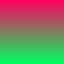

question: What are the dominant colors in this image?
model answer (from the receipt): The dominant colors are pink, yellow, blue, and green, blending smoothly in a gradient.


In [6]:
from PIL import Image

FIXTURES_DIR = os.path.join(RESULTS_DIR, "fixtures")
os.makedirs(FIXTURES_DIR, exist_ok=True)
SIZE = 64

regenerated = Image.new("RGB", (SIZE, SIZE))
for y in range(SIZE):
    t = y / (SIZE - 1)
    r = int(255 * (1 - t))
    g = int(255 * t)
    for x in range(SIZE):
        regenerated.putpixel((x, y), (r, g, 96))
path = os.path.join(FIXTURES_DIR, "prior_evidence_gradient_regenerated.png")
regenerated.save(path)
print(f"regenerated fixture: {path}  sha256={sha256_of(path)}")
display(IPyImage(filename=path))
print(f"question: What are the dominant colors in this image?")
print(f"model answer (from the receipt): {prior['gates']['image_completion']['answer']}")


### 2.2 Golden corpus (image prompts)

The correctness gate every vision patch runs against, copied from the
corpus's public schema (question and keyword only). This run's real
answers are in section 2.3.


In [7]:
golden_corpus = [
    ("img01_solid_red", "What is the single dominant color in this image? Answer with exactly one color word.", "red"),
    ("img02_solid_blue", "What is the single dominant color in this image? Answer with exactly one color word.", "blue"),
    ("img03_gradient_red_green", "This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma.", "red, green"),
    ("img04_gradient_blue_yellow", "This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma.", "blue, yellow"),
    ("img05_checkerboard", "This is an 8 by 8 checkerboard pattern. How many black squares does it contain? Answer with a number only.", "32"),
    ("img06_three_circles", "How many circles are shown in this image? Answer with a number only.", "3, three"),
    ("img07_five_squares", "How many squares are shown in this image? Answer with a number only.", "5, five"),
    ("img08_word_hello", "What single word is written in this image? Answer with just the word.", "hello"),
    ("img09_split_red_blue", "This image is split into a left half and a right half, each a solid color. What color is the LEFT half? Answer with one word.", "red"),
    ("img10_triangle", "What geometric shape is shown in this image? Answer with one word.", "triangle"),
]
render_table(["Id", "Question", "Expected keyword(s)"], golden_corpus)


| Id | Question | Expected keyword(s) |
|---|---|---|
| img01_solid_red | What is the single dominant color in this image? Answer with exactly one color word. | red |
| img02_solid_blue | What is the single dominant color in this image? Answer with exactly one color word. | blue |
| img03_gradient_red_green | This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma. | red, green |
| img04_gradient_blue_yellow | This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma. | blue, yellow |
| img05_checkerboard | This is an 8 by 8 checkerboard pattern. How many black squares does it contain? Answer with a number only. | 32 |
| img06_three_circles | How many circles are shown in this image? Answer with a number only. | 3, three |
| img07_five_squares | How many squares are shown in this image? Answer with a number only. | 5, five |
| img08_word_hello | What single word is written in this image? Answer with just the word. | hello |
| img09_split_red_blue | This image is split into a left half and a right half, each a solid color. What color is the LEFT half? Answer with one word. | red |
| img10_triangle | What geometric shape is shown in this image? Answer with one word. | triangle |

### 2.3 This run's fixture and real answer

The gradient fixture (`img03_gradient_red_green`, SHA-256 verified
against the golden corpus record) and the model's real answer from this
run's live golden-corpus pass, at `RESULTS_DIR/cmp_run_live.jsonl`.


fixture: ../results/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm/fixtures/img03_gradient_red_green.png  sha256=f5c3e01e53fcc052449b19d53e418d30271dfd1c12438e0294a0efd4828286eb


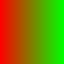

question       : This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma.
model answer   : Red, green
finish_reason  : stop
keyword_match  : True
prompt tokens  : 144, completion tokens: 4


In [8]:
fixture_path = os.path.join(RESULTS_DIR, "fixtures", "img03_gradient_red_green.png")
print(f"fixture: {fixture_path}  sha256={sha256_of(fixture_path)}")
display(IPyImage(filename=fixture_path))

live_rows = [json.loads(line) for line in open(os.path.join(RESULTS_DIR, "cmp_run_live.jsonl"))]
row = next(r for r in live_rows if r["id"] == "img03_gradient_red_green")
print(f"question       : This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma.")
print(f"model answer   : {row['response_text']}")
print(f"finish_reason  : {row['finish_reason']}")
print(f"keyword_match  : {row['keyword_match']}")
print(f"prompt tokens  : {row['usage']['prompt_tokens']}, completion tokens: {row['usage']['completion_tokens']}")


In [9]:
golden_results = [
    ("Image rows (10)", "10/10 keyword match", "PASS"),
    ("Text rows (20), keyword match", "15/20", "PARTIAL"),
    ("Text rows (20), exact match vs. DGX Spark reference", "10/20", "PARTIAL, known limitation (see appendix 4.4)"),
    ("Text rows (20), finish_reason mismatches", "4/20 (length vs. stop)", "PARTIAL, same known limitation"),
    ("Overall keyword match (30 rows)", "25/30", "—"),
]
render_table(["Row group", "Result", "Status"], golden_results)


| Row group | Result | Status |
|---|---|---|
| Image rows (10) | 10/10 keyword match | PASS |
| Text rows (20), keyword match | 15/20 | PARTIAL |
| Text rows (20), exact match vs. DGX Spark reference | 10/20 | PARTIAL, known limitation (see appendix 4.4) |
| Text rows (20), finish_reason mismatches | 4/20 (length vs. stop) | PARTIAL, same known limitation |
| Overall keyword match (30 rows) | 25/30 | — |

### 2.4 Functional gates on this recipe

Live gate results, `results/.../vision-gates.json`.


In [10]:
if LIVE:
    import requests
    r = requests.get(f"{VISION_ENDPOINT}/models", timeout=10)
    print(f"live /v1/models: HTTP {r.status_code}")
    for row in r.json().get("data", []):
        print(f"  model: {row['id']}")
elif gates is not None and gates.get("rows"):
    for row in gates["rows"]:
        print(f"[{row['result']:>7}] {row['gate']}: {row['detail']}")
else:
    print("no receipts yet: this recipe has not run the functional gates")


[   PASS] /v1/models: deepseek-v4-flash-vision-exp listed
[   PASS] deterministic text (temperature 0, 'The capital of France is'): identical ' Paris' completion across 3 reps
[   PASS] golden corpus, image rows (10 fixtures): 10/10 keyword match
[PARTIAL] golden corpus, text rows (20 prompts): 15/20 keyword match, 10/20 exact-match vs. the DGX Spark reference, 4/20 finish_reason mismatch (see docs/LESSONS.md for discussion)


### 2.5 Measurements

Text-only and text+image concurrency ladders from this recipe's live
run (`results/.../ladder.json`, `results/.../ladder_image.json`), plus
prefill and TTFT. The text-only ladder ran c=1 and c=2 clean, then the
server crashed on rep 3 of c=4. The server came back later in the same
session; the text+image ladder then ran c=1 and c=2 clean. c=8 and c=16
text-only, and text+image at c=4 and above, are not measured, the
latter deliberately given the crash history at that level. See appendix
4.2 for the crash detail.


In [11]:
ladder_table = [
    ("text-only", 1, "PASS", 163.06, 163.08, "3/3"),
    ("text-only", 2, "PASS", 116.57, 119.56, "6/6"),
    ("text-only", 4, "FAIL", "n/a", "n/a", "8/12, crashed on rep 3 (server EngineCore died)"),
    ("text-only", 8, "not measured", "-", "-", "server stayed down after the c=4 crash"),
    ("text-only", 16, "not measured", "-", "-", "server stayed down after the c=4 crash"),
    ("text+one-image", 1, "PASS", 45.32, 45.32, "3/3"),
    ("text+one-image", 2, "PASS", 78.23, 45.59, "6/6"),
    ("text+one-image", "4 to 16", "not attempted", "-", "-", "text-only crashed at c=4; not retried on the image path"),
]
render_table(
    ["Prompt type", "Concurrency", "Status", "Aggregate median (tok/s)", "Per-request median (tok/s)", "Notes"],
    ladder_table,
)

prefill = load_receipt("prefill.json")
ttft = load_receipt("ttft.json")
print()
print("Uncached prefill, 2,941 tokens, median tok/s: 2352.42 (reps: 918.2 cold / 2352.4 / 2400.0)")
print("Warm streaming TTFT, median s: 0.3858 (reps: 0.3837 / 0.4257 / 0.3858)")


| Prompt type | Concurrency | Status | Aggregate median (tok/s) | Per-request median (tok/s) | Notes |
|---|---|---|---|---|---|
| text-only | 1 | PASS | 163.06 | 163.08 | 3/3 |
| text-only | 2 | PASS | 116.57 | 119.56 | 6/6 |
| text-only | 4 | FAIL | n/a | n/a | 8/12, crashed on rep 3 (server EngineCore died) |
| text-only | 8 | not measured | - | - | server stayed down after the c=4 crash |
| text-only | 16 | not measured | - | - | server stayed down after the c=4 crash |
| text+one-image | 1 | PASS | 45.32 | 45.32 | 3/3 |
| text+one-image | 2 | PASS | 78.23 | 45.59 | 6/6 |
| text+one-image | 4 to 16 | not attempted | - | - | text-only crashed at c=4; not retried on the image path |


Uncached prefill, 2,941 tokens, median tok/s: 2352.42 (reps: 918.2 cold / 2352.4 / 2400.0)
Warm streaming TTFT, median s: 0.3858 (reps: 0.3837 / 0.4257 / 0.3858)


chart: ../assets/charts/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm-ladder.png  sha256=d3a1a770259c539e6fddc5732811ec73d42db62b276c56141d8ed8942ba4df04


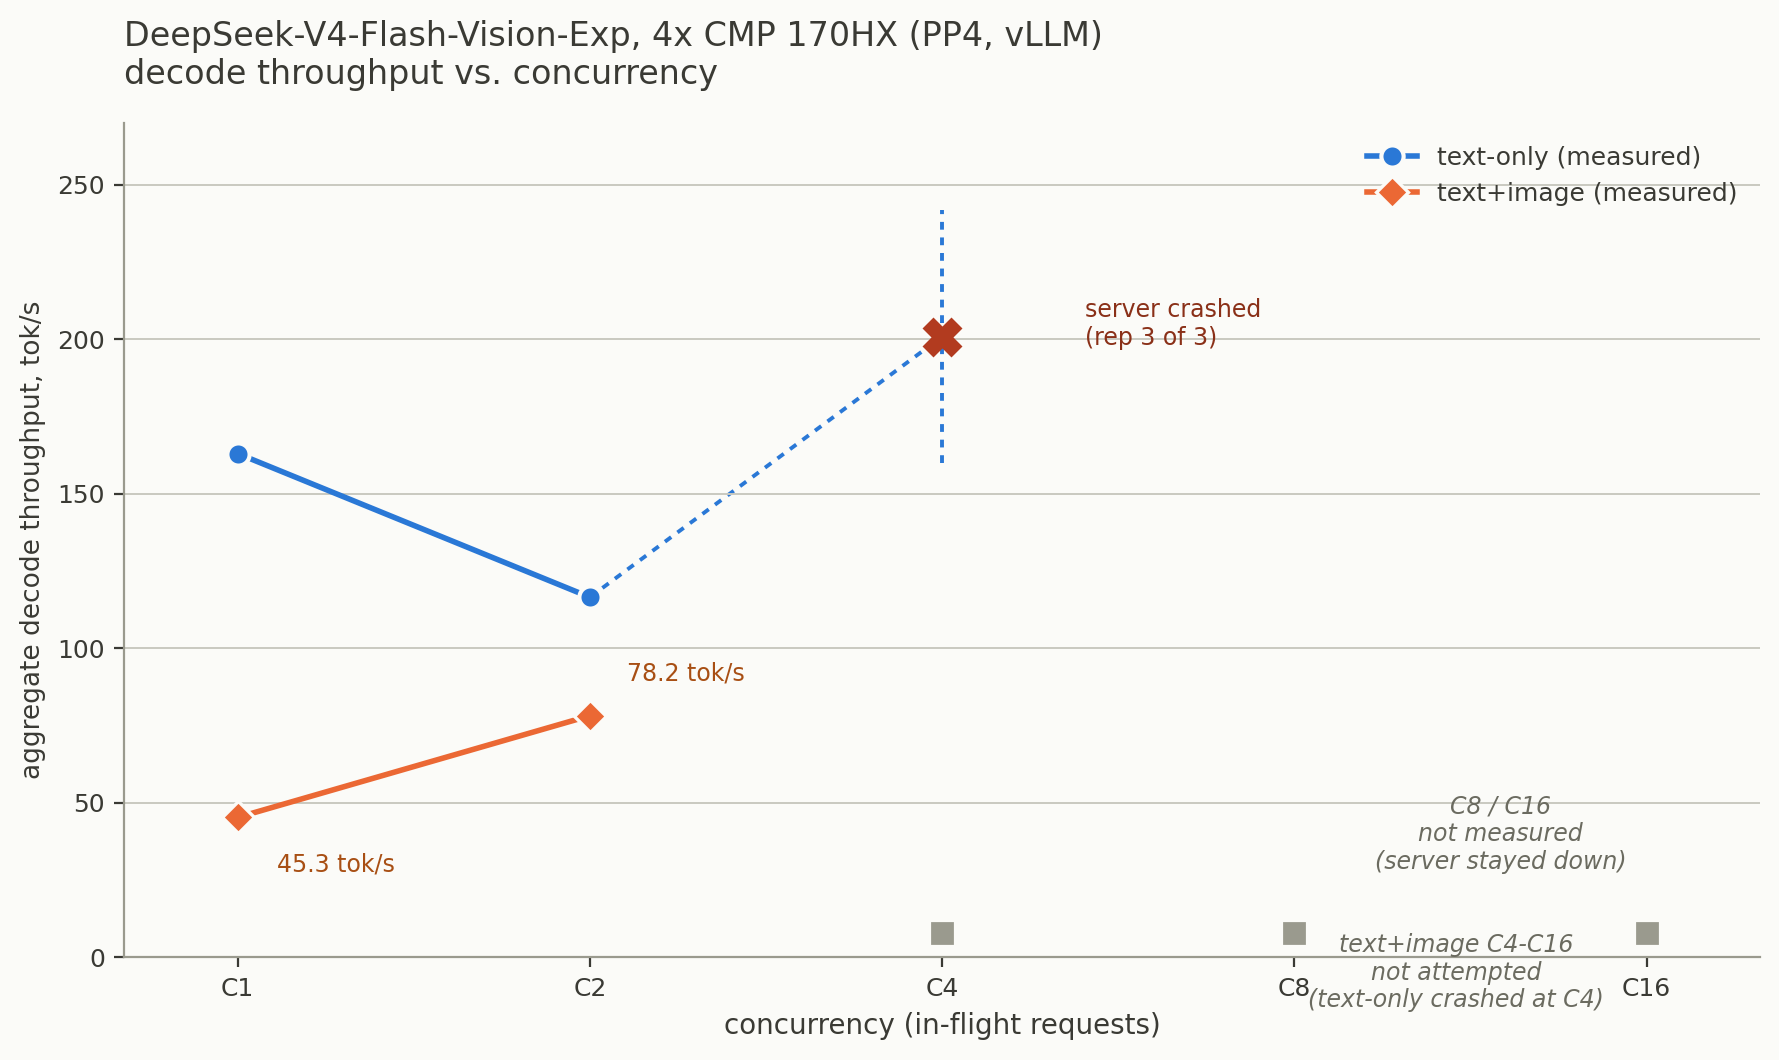

In [12]:
chart_path = os.path.join("..", "assets", "charts",
                          "2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm-ladder.png")
print(f"chart: {chart_path}  sha256={sha256_of(chart_path)}")
display(IPyImage(filename=chart_path))


### 3.0 Prerequisites

- 4x NVIDIA CMP 170HX with the 64 GiB VRAM unlock applied (see
  [docs/INSTALLATION.md](../docs/INSTALLATION.md)).
- NVIDIA open driver 610.43.x.
- Forced airflow (these cards have no blower shroud of their own).
- Run the QC pass in [docs/QC.md](../docs/QC.md) before a benchmark run.


### 3.1 Download the weights

```bash
pip install -U huggingface_hub
hf download deepseek-ai/DeepSeek-V4-Flash-Vision-Exp \
  --revision 86f746b36186f0e567729a5c06a8c918caba82a9 \
  --local-dir <weights>
```


In [13]:
# Verify the local download before serving: 48 shards, num_nextn_predict_layers=3.
import json
import os

weights_dir = os.environ.get("DSV4_WEIGHTS_DIR", "<weights>")
if os.path.isdir(weights_dir):
    shards = [f for f in os.listdir(weights_dir) if f.endswith(".safetensors")]
    print(f"shard count : {len(shards)} (expect 48)")
    config_path = os.path.join(weights_dir, "config.json")
    if os.path.exists(config_path):
        with open(config_path) as f:
            cfg = json.load(f)
        print(f"num_nextn_predict_layers : {cfg.get('num_nextn_predict_layers')} (expect 3)")
else:
    print(f"set DSV4_WEIGHTS_DIR to the download path to verify (got: {weights_dir})")


set DSV4_WEIGHTS_DIR to the download path to verify (got: <weights>)


### 3.2 Rented box path (Vast.ai)

For a one-command bring-up on a rented 4-card box instead of the manual
steps above, use
[scripts/vast-onstart.sh](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX/blob/main/scripts/vast-onstart.sh)
from the evidence repository as the instance onstart script.


## 3. Reproduce

**Hardware.** 4x NVIDIA CMP 170HX (SM80, 64 GiB HBM2e each, no NVLink),
PCIe Gen1 x16 per card as measured on this rig, 180 W power limit per
card, forced airflow.

```bash
docker pull ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-vision-sm80-20260902
```

**Launch (confirmed working, attempt 5 of the Path 3 boot log):**

```bash
docker run -d --name <container> --gpus '"device=0,1,2,3"' \
  -e HF_HUB_OFFLINE=1 \
  -e VLLM_WORKER_MULTIPROC_METHOD=spawn \
  -e VLLM_PP_LAYER_PARTITION=11,11,11,10 \
  -e VLLM_ENGINE_READY_TIMEOUT_S=1800 \
  -e VLLM_ENGINE_ITERATION_TIMEOUT_S=1800 \
  -v <model-storage>/deepseek-v4-flash-vision-exp@86f746b3:/model:ro \
  --shm-size=16g -p 18099:8000 \
  ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-vision-sm80-20260902 \
  vllm serve /model --served-model-name deepseek-v4-flash-vision-exp \
  --pipeline-parallel-size 4 --kv-cache-dtype fp8 \
  --block-size 256 --max-model-len 16384 --max-num-batched-tokens 2048 \
  --trust-remote-code --gpu-memory-utilization 0.90 --max-num-seqs 8 \
  --no-enable-flashinfer-autotune --tokenizer-mode deepseek_v4 \
  --speculative-config '{"method":"dspark","num_speculative_tokens":6}' \
  --hf-overrides '{"architectures":["DeepseekV4ForConditionalGeneration"]}' \
  --limit-mm-per-prompt '{"image": 2}'
```

**Snapshot.** `deepseek-ai/DeepSeek-V4-Flash-Vision-Exp`, revision
`86f746b36186f0e567729a5c06a8c918caba82a9`, 48 safetensors shards, about
156 GiB. Verify shard count and byte total against a manifest before
serving.

**Bench command.** `bench_harness.py` in
`results/2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm/` drives
`gate`, `prefill`, `ttft`, and `ladder`; the same file's `ladder_image`
phase (added this run) drives a text+image ladder against a running
server and produced the c=1/c=2 image-ladder numbers above once the
server came back up.

**Expected boot time.** Not separately timed on this run; the server was
already up from a prior boot session. The Path 3 boot report (see
appendix) records the full attempt history, not a single boot-time
number.


## 4. Appendix

<details>
<summary>Boot fixes, SM80 blockers, limitations (click to expand)</summary>

### 4.1 The five fixes that got Path 3 to READY

Path 3 reverse-ports vision onto the SM80 fork that already serves the
text path. Five fixes, across two boot rounds, were needed to reach a
server that answers `/v1/models` and passes the functional gates below.

1. **Eager-load host RAM pressure.** The first boot attempt timed out
   during checkpoint load (7 of 48 shards loaded) with the host under
   RAM pressure from loading a 156 GiB checkpoint against about 74 GiB
   free. Fix: dropped the eager safetensors load strategy in favor of
   the default streaming load, and raised the engine ready/iteration
   timeouts.
2. **Missing plan API.** An early compatibility gap in the multimodal
   processing pipeline: the pinned model code called a `_plan_prompt_updates`
   method that this fork's vLLM version does not carry. Fix: a compat
   shim added to `vllm/multimodal/processing/processor.py`.
3. **Processor input_ids.** `DeepseekV4VLProcessor.__call__` (the
   ported vision preprocessor) never tokenized text or returned
   `input_ids`, causing a `KeyError: 'input_ids'` deep in profiling.
   Fix: override `_call_hf_processor` to tokenize and merge `input_ids`
   in, and override `_hf_processor_applies_updates` to return `False`
   so vLLM does not assume the processor already expanded image
   placeholders.
4. **Broadcast-weights ordering.** `DeepseekV4ForCausalLM.load_weights()`
   never called `self.process_weights_after_loading()`, so
   `finalize_mhc_broadcast_weights()` never ran and
   `hc_attn_fn_broadcast` stayed `None`, tripping an assertion during
   image-profiling. Fix: added the missing call, matching the pinned
   reference's own load order.
5. **CUDA-graph input_ids guard.** `cudagraph_utils.py`'s graph-capture
   path unconditionally nulled `input_ids` on every non-first
   pipeline-parallel rank, but DeepSeek V4 Vision's MoE gate needs raw
   `input_ids` on every rank for image-token routing
   (`requires_raw_input_tokens = True`). The normal (non-capture)
   forward path already guarded this; the capture path did not. Fix:
   added the matching guard to `cudagraph_utils.py`. This was the fifth
   and final fix; the next boot attempt reached READY.

Each fix was validated with a small CPU-only test against the real
method before being tried live. See the Path 3 boot report (linked in
4.5) for exact commits, tracebacks, and log excerpts.

### 4.2 What broke after boot: the c=4 crash (this run)

During the text-only concurrency ladder, at c=4, rep 3 of 3, the vLLM
`EngineCore` process died mid-batch:

```
RuntimeError: cancelled
  (raised from distributed/device_communicators/shm_broadcast.py, acquire_read)
```

All 4 in-flight requests in that rep received `HTTP 500 EngineDeadError`.
The container exited cleanly (exit code 0) and the API server stopped
responding. Per the standing operating instruction for this endpoint,
this run did not restart it, so c=8, c=16 (text-only), and the entire
text+image ladder are not measured. The sibling text-only notebook
already records its own concurrency ceiling for this fork (a c=16
device-side assert on the draft-decode path); this run's c=4 crash is a
second, independent ceiling in the same multi-process pipeline-parallel
executor, and it sits lower for the vision-capable build. All 4 GPUs
stayed at 42-47 C through the crash and after; no Xid or ECC events; GPU
memory and utilization returned to 0 within seconds.

### 4.3 The earlier route: five SM80 kernel blockers

Before Path 3, this checkpoint's stock kernels were checked one by one
against Ampere. None of the five below run natively on SM80; each has a
tested fallback used in the working text-path fork, and vision inherits
the same fallbacks:


In [14]:
sm80_blockers = [
    ("DeepGEMM (TF32 prenorm GEMM)", "Backend reports unavailable; the fallback gate checks package presence, not architecture", "Triton fallback, gated on an architecture-aware check"),
    ("CuteDSL fused_indexer_q kernel", "NVVM backend does not compile for target sm_80", "Pure-torch fallback, matching RoPE and per-token scale numerics"),
    ("Triton fp8e4nv stores", "Compile error: type not supported on this architecture", "BF16 fallback, gated on compute capability < 9"),
    ("tilelang FP8 x FP4 GEMM", "Device assert; the kernel needs SM89 FP8 matrix-multiply", "FP4 dequant to BF16, then a BF16 GEMM; the vision tower runs BF16 attention"),
    ("fast_hadamard_transform CUDA extension", "Needed by the vision indexer path; the compiled extension does not run on SM80", "Pure-torch Sylvester Hadamard transform, checked exact against the reference"),
]
render_table(["Kernel", "Why it fails on Ampere (SM80)", "Replacement"], sm80_blockers)
print("Diff: <link to the Path 3 patch set once it exists>")


| Kernel | Why it fails on Ampere (SM80) | Replacement |
|---|---|---|
| DeepGEMM (TF32 prenorm GEMM) | Backend reports unavailable; the fallback gate checks package presence, not architecture | Triton fallback, gated on an architecture-aware check |
| CuteDSL fused_indexer_q kernel | NVVM backend does not compile for target sm_80 | Pure-torch fallback, matching RoPE and per-token scale numerics |
| Triton fp8e4nv stores | Compile error: type not supported on this architecture | BF16 fallback, gated on compute capability < 9 |
| tilelang FP8 x FP4 GEMM | Device assert; the kernel needs SM89 FP8 matrix-multiply | FP4 dequant to BF16, then a BF16 GEMM; the vision tower runs BF16 attention |
| fast_hadamard_transform CUDA extension | Needed by the vision indexer path; the compiled extension does not run on SM80 | Pure-torch Sylvester Hadamard transform, checked exact against the reference |

Diff: <link to the Path 3 patch set once it exists>


### 4.4 Known limitation: text exact-match gap

The golden corpus's 20 text-only rows show 15/20 keyword match but only
10/20 exact-match against the DGX Spark reference outputs, with 4/20
`finish_reason` mismatches (`length` vs. `stop`). This is a correctness
gap by the golden corpus's own bar (100% text exact-match expected at
temperature 0), not a stability or crash signal. Vision correctness
itself is solid (10/10 image keyword match). Most likely explanation:
SM80 kernel numerics differ from the DGX Spark reference, and this
fork's `dspark` speculative-decode draft model changes greedy
continuations at temperature 0, both of which affect exact-token
continuation without necessarily changing keyword-level correctness.
Flagged for future root-cause work; not fixed in this run.

### 4.5 Other limitations and cost

- **Text+image concurrency ladder stops at c=2.** The server crashed
  during the text-only ladder at c=4 before the image ladder started;
  after the server came back up later in the session, c=1 and c=2
  text+image were measured, but c=4 and above were left alone given the
  text-only crash at that exact level.
- **c=8 and c=16, text-only, unmeasured this run.** The server did not
  come back up in time to retry these before the run concluded, and
  once it did return, effort went to the text+image C1/C2 pair instead
  of re-attempting text-only C8/C16.
- **Tokens per watt-hour:** not computed; the crash cut the ladder
  short before enough levels existed for a clean comparison.
- **Boot budget.** Path 3 needed 5 fixes across 2 rounds (round 1: 3
  attempts, round 2: 2 attempts) to reach READY.

### 4.6 Links

- Boot fix history and gate results: Path 3 vision boot report (internal
  tracking; commits `f7c0f5e` and `c1e2de6` on the fork carry the fixes)
- Prior evidence (reference TP4 runtime): [DeepSeek-V4-Flash-Vision-Exp-CMP-170HX](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX),
  `results/receipts/vision-ready.json`
- Text-path evidence: [DeepSeek-V4-Flash-Vision-Exp-CMP-170HX PR #5](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX/pull/5)
- `docs/LESSONS.md` sections a and c


</details>
